In [1]:
import tensorflow as tf
import numpy as np

# Load model
model = tf.keras.models.load_model('../Models/best_model.keras', compile=False)

# Create a random test image
test_img = np.random.rand(1, 100, 100, 1).astype('float32')

# Test 3 times - predictions should be IDENTICAL for the same input
for i in range(3):
    pred = model(test_img, training=False).numpy()
    print(f"Test {i+1}:")
    print(f"  Predicted class: {pred.argmax()}")
    print(f"  Max probability: {pred.max():.6f}")
    print(f"  Top 3 classes: {pred[0].argsort()[-3:][::-1]}")
    print()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6
Test 1:
  Predicted class: 24
  Max probability: 0.175293
  Top 3 classes: [24 15 16]

Test 2:
  Predicted class: 24
  Max probability: 0.175293
  Top 3 classes: [24 15 16]

Test 3:
  Predicted class: 24
  Max probability: 0.175293
  Top 3 classes: [24 15 16]



In [2]:
import tensorflow as tf
import numpy as np
import os

# Path to your model
MODEL_PATH = '../Models/best_model.keras'  # or 'Models/best_model.keras'

# Path to your data (same as training)
DATA_DIR = '../data'
TRAIN_SUBDIR = 'train'
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 1337

print("=" * 50)
print("TESTING MODEL")
print("=" * 50)

# Check if model exists
if not os.path.exists(MODEL_PATH):
    print(f"ERROR: Model not found at {MODEL_PATH}")
    exit()

print(f"\n1. Model file size: {os.path.getsize(MODEL_PATH) / (1024*1024):.2f} MB")

# Load validation data (same as training)
from tensorflow.keras.utils import image_dataset_from_directory

train_dir = os.path.join(DATA_DIR, TRAIN_SUBDIR)

val_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale',
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

print(f"2. Validation dataset loaded: {len(val_ds)} batches")
print(f"3. Class names: {val_ds.class_names[:10]}...")  # Show first 10

# Load model
print("\n4. Loading model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)  # Removed safe_mode
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print(f"   Input shape: {model.input_shape}")
print(f"   Output shape: {model.output_shape}")

# Evaluate on validation data
print("\n5. Evaluating on validation data...")
val_loss, val_acc = model.evaluate(val_ds, verbose=1)

print("\n" + "=" * 50)
print(f"RESULT: Validation Accuracy = {val_acc*100:.2f}%")
print(f"RESULT: Validation Loss = {val_loss:.4f}")
print("=" * 50)

if val_acc > 0.80:
    print("\n✅ Model looks GOOD! Upload this to Hugging Face.")
elif val_acc > 0.50:
    print("\n⚠️  Model is okay but could be better. Consider retraining.")
else:
    print("\n❌ Model is BROKEN! This is the wrong checkpoint. Retrain or use a different checkpoint.")

# Test on a single batch
print("\n6. Testing on a single batch...")
for images, labels in val_ds.take(1):
    predictions = model(images, training=False).numpy()
    pred_classes = predictions.argmax(axis=1)
    true_classes = labels.numpy().argmax(axis=1)
    
    correct = (pred_classes == true_classes).sum()
    print(f"   Batch accuracy: {correct}/{len(pred_classes)} = {correct/len(pred_classes)*100:.1f}%")
    
    # Show first 5 predictions
    print("\n   First 5 predictions:")
    for i in range(min(5, len(pred_classes))):
        true_label = val_ds.class_names[true_classes[i]]
        pred_label = val_ds.class_names[pred_classes[i]]
        confidence = predictions[i][pred_classes[i]] * 100
        status = "✓" if pred_classes[i] == true_classes[i] else "✗"
        print(f"   {status} True: {true_label}, Predicted: {pred_label} ({confidence:.1f}%)")

TESTING MODEL

1. Model file size: 16.43 MB
Found 28800 files belonging to 36 classes.
Using 5760 files for validation.
2. Validation dataset loaded: 180 batches
3. Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...

4. Loading model...
   Input shape: (None, 100, 100, 1)
   Output shape: (None, 36)

5. Evaluating on validation data...
180/180 [==============================] - 3s 11ms/step - loss: 0.4331 - accuracy: 0.9128

RESULT: Validation Accuracy = 91.28%
RESULT: Validation Loss = 0.4331

✅ Model looks GOOD! Upload this to Hugging Face.

6. Testing on a single batch...
   Batch accuracy: 32/32 = 100.0%

   First 5 predictions:
   ✓ True: 7, Predicted: 7 (87.9%)
   ✓ True: v, Predicted: v (99.1%)
   ✓ True: w, Predicted: w (78.0%)
   ✓ True: s, Predicted: s (99.1%)
   ✓ True: 5, Predicted: 5 (97.1%)


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load the original model
original_model = tf.keras.models.load_model('../Models/best_model.keras', compile=False)

print("Original model layers:")
for i, layer in enumerate(original_model.layers):
    print(f"{i}: {layer.name} - {type(layer).__name__}")

# Create new model WITHOUT data augmentation
# Skip layers: input_1 (0), data_augmentation (1)
# Keep: rescaling (2) onwards

inputs = layers.Input(shape=(100, 100, 1))

# Start from the rescaling layer (layer 2)
x = inputs
for layer in original_model.layers[2:]:  # Skip input and augmentation
    x = layer(x)

# Create new model
inference_model = models.Model(inputs, x, name='inference_model')

# Copy weights (they should already be there since we're reusing layers)
inference_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Save the inference model
inference_model.save('../Models/best_model_inference.keras')

print("\n✅ Inference model saved to Models/best_model_inference.keras")
print(f"File size: {os.path.getsize('../Models/best_model_inference.keras') / (1024*1024):.2f} MB")

# Test it
import numpy as np
test_img = np.random.rand(1, 100, 100, 1).astype('float32')

pred1 = inference_model(test_img, training=False).numpy()
pred2 = inference_model(test_img, training=False).numpy()
pred3 = inference_model(test_img, training=False).numpy()

print("\nTesting consistency (should be identical):")
print(f"Test 1 top class: {pred1.argmax()}, prob: {pred1.max():.6f}")
print(f"Test 2 top class: {pred2.argmax()}, prob: {pred2.max():.6f}")
print(f"Test 3 top class: {pred3.argmax()}, prob: {pred3.max():.6f}")
print(f"All identical: {np.allclose(pred1, pred2) and np.allclose(pred2, pred3)}")

Original model layers:
0: input_1 - InputLayer
1: data_augmentation - Sequential
2: rescaling - Rescaling
3: conv2d - Conv2D
4: batch_normalization - BatchNormalization
5: conv2d_1 - Conv2D
6: batch_normalization_1 - BatchNormalization
7: max_pooling2d - MaxPooling2D
8: dropout - Dropout
9: conv2d_2 - Conv2D
10: batch_normalization_2 - BatchNormalization
11: conv2d_3 - Conv2D
12: batch_normalization_3 - BatchNormalization
13: max_pooling2d_1 - MaxPooling2D
14: dropout_1 - Dropout
15: conv2d_4 - Conv2D
16: batch_normalization_4 - BatchNormalization
17: conv2d_5 - Conv2D
18: batch_normalization_5 - BatchNormalization
19: max_pooling2d_2 - MaxPooling2D
20: dropout_2 - Dropout
21: global_average_pooling2d - GlobalAveragePooling2D
22: dense - Dense
23: batch_normalization_6 - BatchNormalization
24: dropout_3 - Dropout
25: dense_1 - Dense
26: batch_normalization_7 - BatchNormalization
27: dropout_4 - Dropout
28: dense_2 - Dense

✅ Inference model saved to Models/best_model_inference.keras
Fi

In [5]:
# Test on validation data
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

DATA_DIR = '../data'
TRAIN_SUBDIR = 'train'

val_ds = image_dataset_from_directory(
    f'{DATA_DIR}/{TRAIN_SUBDIR}',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(100, 100),
    color_mode='grayscale',
    validation_split=0.2,
    subset='validation',
    seed=1337
)

inference_model = tf.keras.models.load_model('../Models/best_model_inference.keras')
val_loss, val_acc = inference_model.evaluate(val_ds)
print(f"Inference model accuracy: {val_acc*100:.2f}%")

Found 28800 files belonging to 36 classes.
Using 5760 files for validation.
180/180 [==============================] - 3s 13ms/step - loss: 0.4331 - accuracy: 0.9128
Inference model accuracy: 91.28%


In [7]:
import tensorflow as tf
import numpy as np

# Load inference model
model = tf.keras.models.load_model('../Models/best_model_inference.keras')

# Test with 3 different random images
for i in range(3):
    test_img = np.random.rand(1, 100, 100, 1).astype('float32')
    pred = model.predict(test_img, verbose=0)
    print(f"Test {i+1}: Class {pred.argmax()}, Confidence {pred.max():.4f}")

# Now test on validation data
from tensorflow.keras.utils import image_dataset_from_directory

val_ds = image_dataset_from_directory(
    '../data/train',
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(100, 100),
    color_mode='grayscale',
    validation_split=0.2,
    subset='validation',
    seed=1337
)

# Evaluate
loss, acc = model.evaluate(val_ds)
print(f"\n✅ Validation Accuracy: {acc*100:.2f}%")

Test 1: Class 24, Confidence 0.1753
Test 2: Class 24, Confidence 0.1759
Test 3: Class 24, Confidence 0.1765
Found 28800 files belonging to 36 classes.
Using 5760 files for validation.
180/180 [==============================] - 2s 12ms/step - loss: 0.4331 - accuracy: 0.9128

✅ Validation Accuracy: 91.28%


Training image stats:
  Shape: (100, 100)
  Range: 0 to 251
  Mean: 10.8


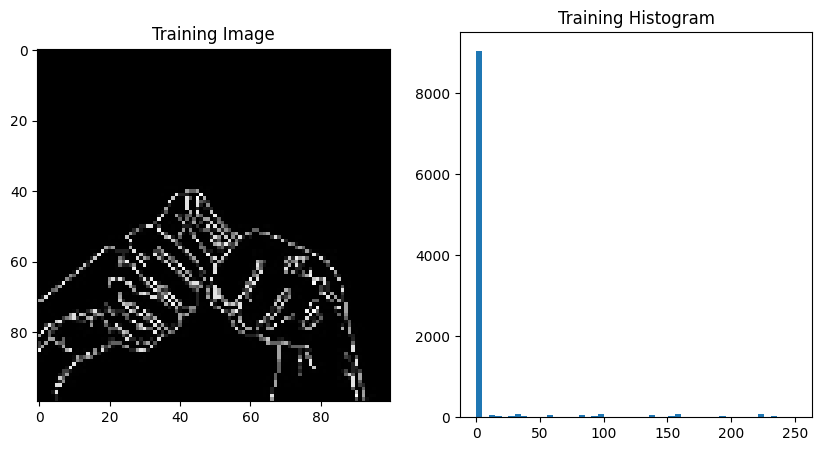

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load a training image
train_img = cv2.imread('../data/train/a/5.jpg', cv2.IMREAD_GRAYSCALE)  # Pick any image
train_resized = cv2.resize(train_img, (100, 100))

print(f"Training image stats:")
print(f"  Shape: {train_resized.shape}")
print(f"  Range: {train_resized.min()} to {train_resized.max()}")
print(f"  Mean: {train_resized.mean():.1f}")

# Show it
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(train_resized, cmap='gray')
plt.title("Training Image")
plt.subplot(1,2,2)
plt.hist(train_resized.flatten(), bins=50)
plt.title("Training Histogram")
plt.show()